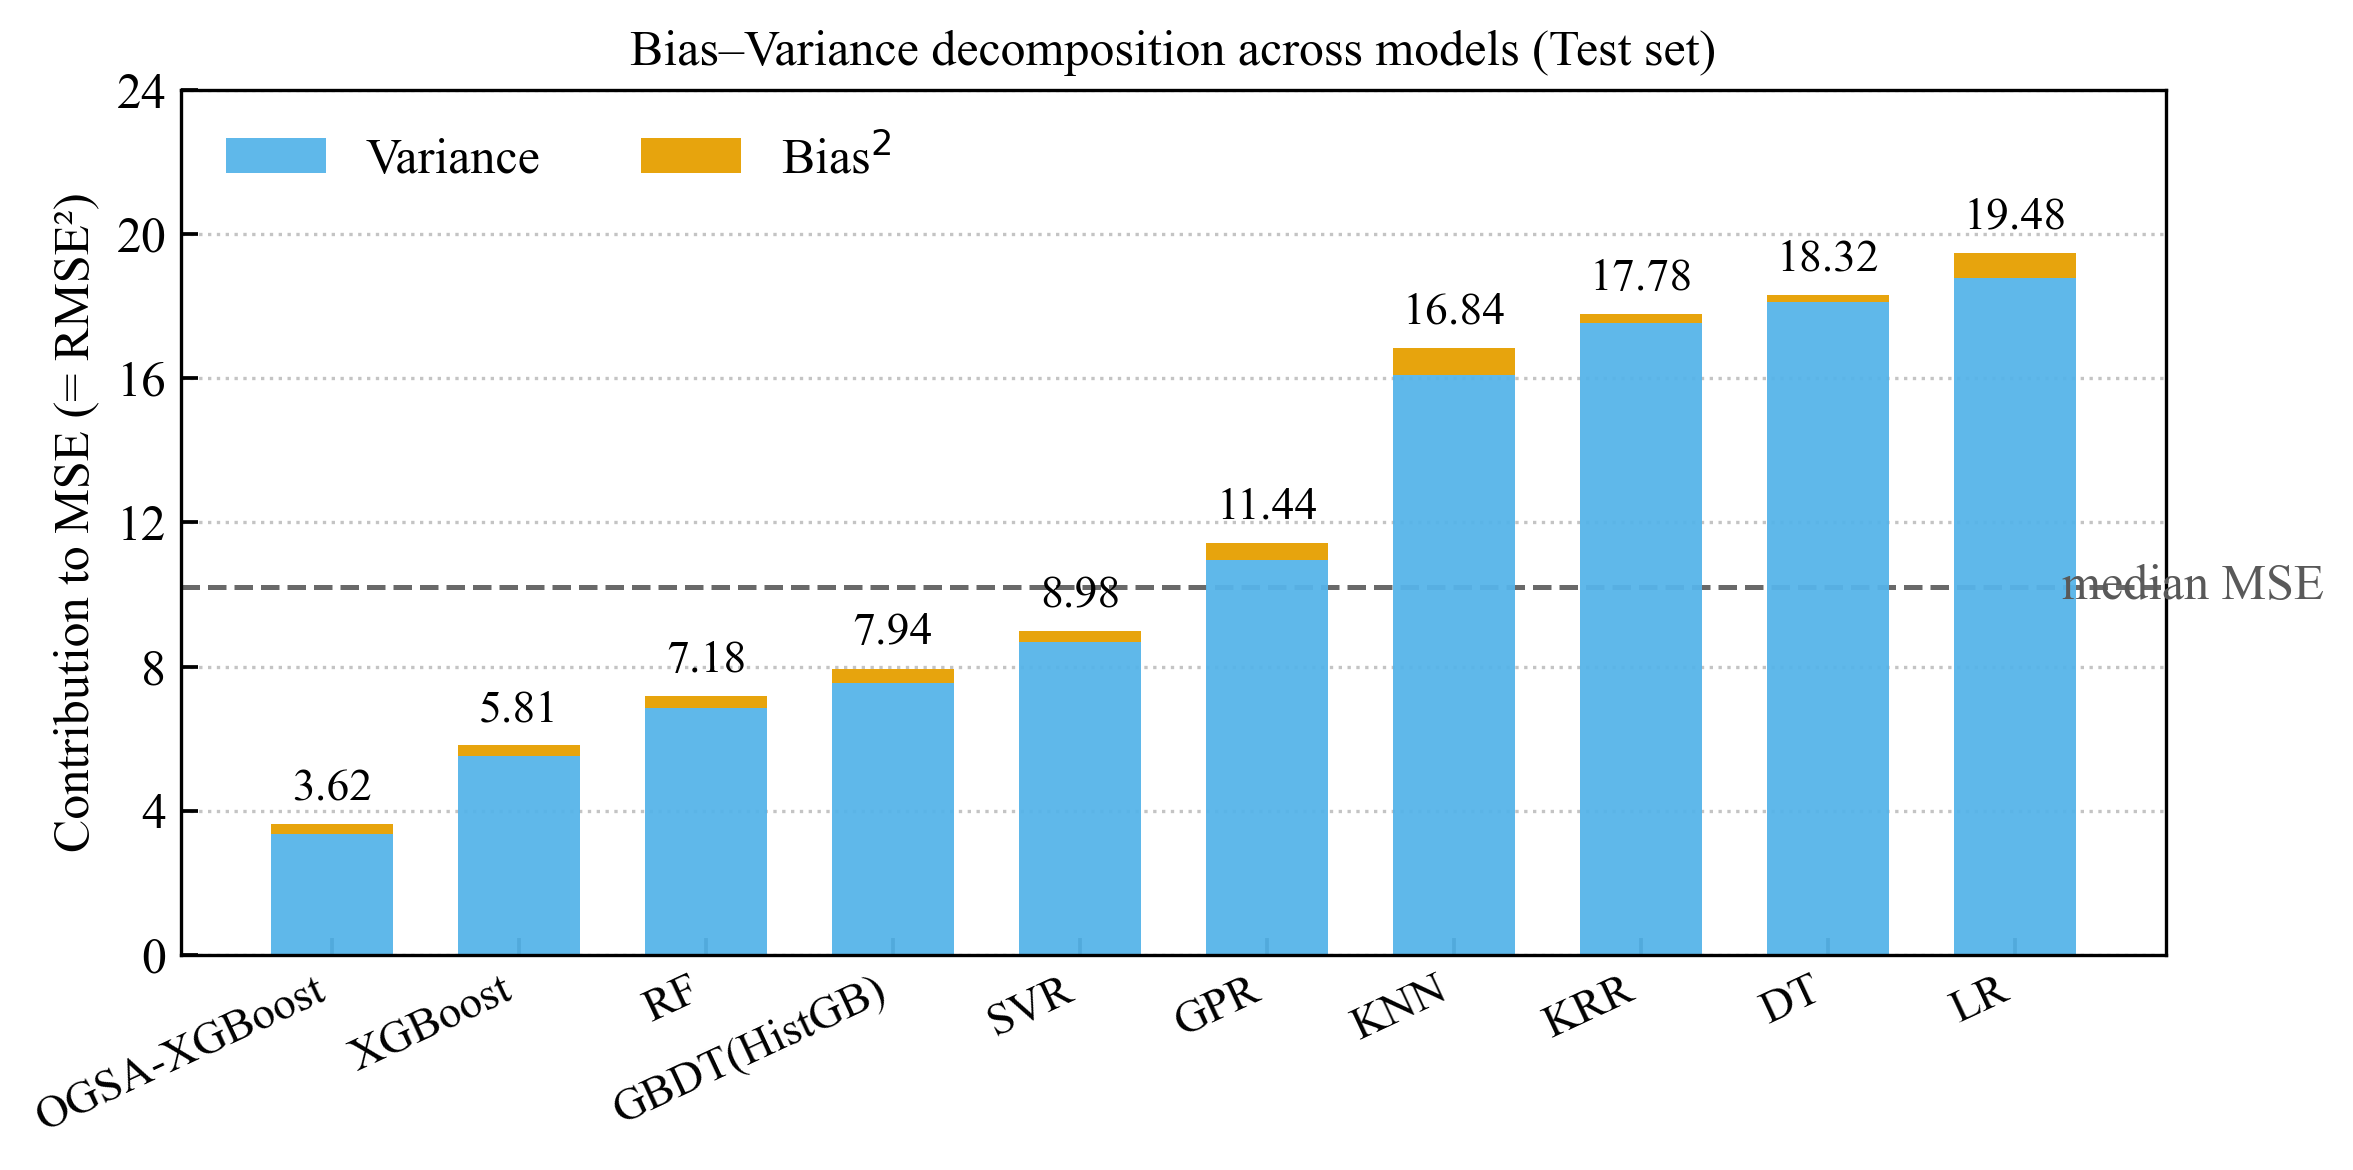

In [5]:
import os
import glob
import unicodedata
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["axes.unicode_minus"] = False

ROOT_DIR = "RMR_Exports"

FIGSIZE_MAIN = (8, 4)
DPI = 300

C_VAR = "#56B4E9"
C_B2 = "#E69F00"
C_MED = "0.35"

def _norm(s):
    if not isinstance(s, str):
        return ""
    return unicodedata.normalize("NFKC", s).strip().lower()

def pick_test_sheet(xl):
    for nm in xl.sheet_names:
        if _norm(nm) in ("sheet3", "sheet 3"):
            return nm
    for nm in xl.sheet_names:
        nmn = _norm(nm)
        if ("test" in nmn) or ("测试" in nmn):
            return nm
    return xl.sheet_names[-1]

def pick_true_pred_columns(df):
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        raise ValueError("No numeric columns for y_true/y_pred.")
    sc_t = {
        c: (10 if any(k in _norm(c) for k in ["true", "真实", "label", "target", "y_true", "rmr_true", "true_rmr"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    sc_p = {
        c: (10 if any(k in _norm(c) for k in ["pred", "预测", "estimate", "y_pred", "rmr_pred", "pred_rmr", "model"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    tcol = max(num_cols, key=lambda x: sc_t.get(x, 0))
    pcol = max(num_cols, key=lambda x: sc_p.get(x, 0))
    if tcol == pcol or (sc_t[tcol] < 5 and sc_p[pcol] < 5):
        combos = [
            ("True", "Pred"),
            ("真实", "预测"),
            ("RMR_true", "RMR_pred"),
            ("True_RMR", "Pred_RMR"),
            ("y_true", "y_pred"),
            ("Label", "Model"),
            ("RMR", "Pred_RMR"),
        ]
        low = {_norm(c): c for c in df.columns}
        for a, b in combos:
            if _norm(a) in low and _norm(b) in low:
                tcol, pcol = low[_norm(a)], low[_norm(b)]
                break
    if tcol == pcol:
        if len(num_cols) >= 2:
            tcol, pcol = num_cols[0], num_cols[1]
        else:
            raise ValueError("Cannot determine distinct true/pred columns.")
    return tcol, pcol

def parse_model_name(fp):
    base = os.path.basename(fp)
    name = os.path.splitext(base)[0]
    if name == "SVM":
        name = "SVR"
    return name

def bias_var_mse(e):
    e = np.asarray(e, dtype=float)
    e = e[~np.isnan(e)]
    if e.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    bias = float(np.mean(e))
    mse = float(np.mean(e ** 2))
    var_e = float(np.mean((e - bias) ** 2))
    rmse = float(np.sqrt(mse))
    return bias, var_e, mse, rmse

files = sorted(glob.glob(os.path.join(ROOT_DIR, "*.xlsx")))
if not files:
    raise FileNotFoundError(f"未在 {ROOT_DIR} 找到 .xlsx 文件。")

rows = []
per_model_raw = {}
for fp in files:
    model = parse_model_name(fp)
    try:
        xl = pd.ExcelFile(fp, engine="openpyxl")
    except Exception:
        xl = pd.ExcelFile(fp)
    df = xl.parse(pick_test_sheet(xl))
    tcol, pcol = pick_true_pred_columns(df)
    y_true = pd.to_numeric(df[tcol], errors="coerce").to_numpy()
    y_pred = pd.to_numeric(df[pcol], errors="coerce").to_numpy()
    m = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[m], y_pred[m]
    if y_true.size == 0:
        continue

    e = y_pred - y_true
    bias, var_e, mse, rmse = bias_var_mse(e)

    rows.append({
        "Model": model,
        "N_test": int(e.size),
        "Bias": bias,
        "AbsBias": abs(bias),
        "Var_e": var_e,
        "Std_e": float(np.sqrt(var_e)) if np.isfinite(var_e) else np.nan,
        "MSE": mse,
        "RMSE": rmse,
        "Bias2": bias ** 2,
        "Share_Var": (var_e / mse) if (mse > 0 and np.isfinite(var_e)) else np.nan,
        "Share_Bias2": ((bias ** 2) / mse) if mse > 0 else np.nan
    })
    per_model_raw[model] = (y_true, y_pred)

if not rows:
    raise RuntimeError("没有可计算的模型。")

df_all = (
    pd.DataFrame(rows)
    .sort_values(["RMSE", "AbsBias", "Std_e"], ascending=[True, True, True])
    .reset_index(drop=True)
)

models = df_all["Model"].tolist()
x = np.arange(len(models))
var_vals = df_all["Var_e"].to_numpy()
bias2_vals = df_all["Bias2"].to_numpy()
mse_vals = df_all["MSE"].to_numpy()
rmse_vals = df_all["RMSE"].to_numpy()

fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, dpi=DPI)

ax.bar(x, var_vals, width=0.65, color=C_VAR, alpha=0.95, label="Variance", zorder=2)
ax.bar(x, bias2_vals, width=0.65, bottom=var_vals, color=C_B2, alpha=0.95, label=r"Bias$^2$", zorder=2)

ymax = mse_vals.max() if mse_vals.size else 1.0
for xi, mse, rmse in zip(x, mse_vals, rmse_vals):
    ax.text(xi, mse + 0.02 * ymax, f"{mse:.2f}", ha="center", va="bottom", fontsize=11)

median_mse = float(np.nanmedian(mse_vals))
ax.axhline(median_mse, color=C_MED, lw=1.2, ls="--", alpha=0.9, zorder=1)
ax.text(x[-1] + 0.25, median_mse, "median MSE", ha="left", va="center", fontsize=12, color=C_MED)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=25, ha="right", fontsize=11)
ax.set_ylabel("Contribution to MSE (= RMSE²)", fontsize=12)
ax.set_title("Bias–Variance decomposition across models (Test set)", pad=6, fontsize=12)

upper = ymax * 1.22 if ymax > 0 else 1.0
upper = 4 * int(np.ceil(upper / 4.0))
ax.set_ylim(0, upper)
ax.yaxis.set_major_locator(MultipleLocator(4))

ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.75)
ax.tick_params(which="both", direction="in", length=4, width=0.9)
ax.tick_params(axis="y", which="major", labelsize=12)
ax.legend(frameon=False, fontsize=12, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()

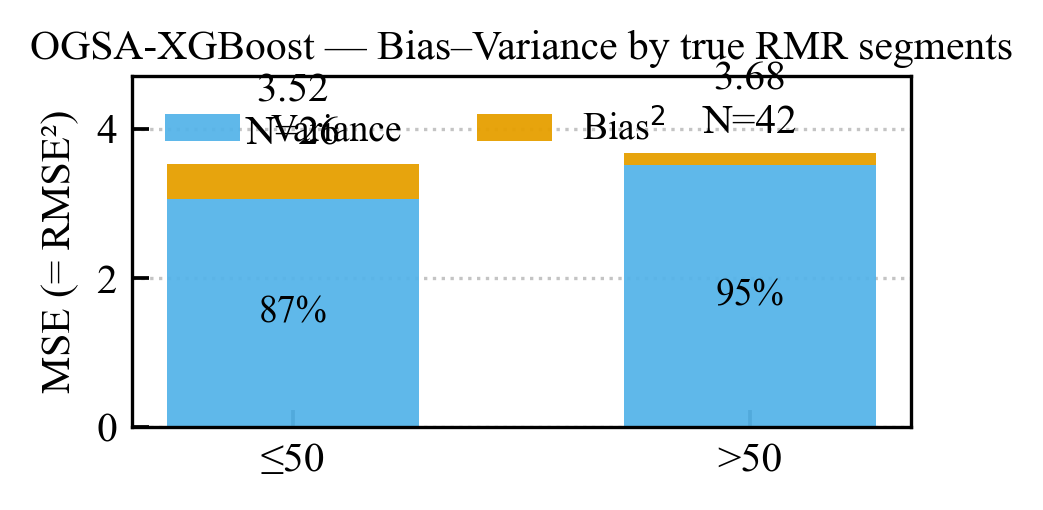

In [6]:
import os
import glob
import unicodedata
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["font.family"] = "Times New Roman"
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["axes.unicode_minus"] = False

ROOT_DIR = "RMR_Exports"

FIGSIZE_OGSA = (3.2, 1.8)
DPI = 300

C_VAR = "#56B4E9"
C_B2 = "#E69F00"

def _norm(s):
    if not isinstance(s, str):
        return ""
    return unicodedata.normalize("NFKC", s).strip().lower()

def pick_test_sheet(xl):
    for nm in xl.sheet_names:
        if _norm(nm) in ("sheet3", "sheet 3"):
            return nm
    for nm in xl.sheet_names:
        nmn = _norm(nm)
        if ("test" in nmn) or ("测试" in nmn):
            return nm
    return xl.sheet_names[-1]

def pick_true_pred_columns(df):
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    sc_t = {
        c: (10 if any(k in _norm(c) for k in ["true", "真实", "label", "target", "y_true", "rmr_true", "true_rmr"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    sc_p = {
        c: (10 if any(k in _norm(c) for k in ["pred", "预测", "estimate", "y_pred", "rmr_pred", "pred_rmr", "model"]) else 0)
        + (2 if "rmr" in _norm(c) else 0)
        for c in num_cols
    }
    tcol = max(num_cols, key=lambda x: sc_t.get(x, 0))
    pcol = max(num_cols, key=lambda x: sc_p.get(x, 0))
    if tcol == pcol or (sc_t[tcol] < 5 and sc_p[pcol] < 5):
        combos = [
            ("True", "Pred"),
            ("真实", "预测"),
            ("RMR_true", "RMR_pred"),
            ("True_RMR", "Pred_RMR"),
            ("y_true", "y_pred"),
            ("Label", "Model"),
            ("RMR", "Pred_RMR"),
        ]
        low = {_norm(c): c for c in df.columns}
        for a, b in combos:
            if _norm(a) in low and _norm(b) in low:
                tcol, pcol = low[_norm(a)], low[_norm(b)]
                break
    if tcol == pcol:
        if len(num_cols) >= 2:
            tcol, pcol = num_cols[0], num_cols[1]
        else:
            raise ValueError("Cannot determine distinct true/pred columns.")
    return tcol, pcol

def parse_model_name(fp):
    base = os.path.basename(fp)
    name = os.path.splitext(base)[0]
    if name == "SVM":
        name = "SVR"
    return name

def bias_var_mse(e):
    e = np.asarray(e, dtype=float)
    e = e[~np.isnan(e)]
    if e.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    bias = float(np.mean(e))
    mse = float(np.mean(e ** 2))
    var_e = float(np.mean((e - bias) ** 2))
    rmse = float(np.sqrt(mse))
    return bias, var_e, mse, rmse

def _is_ogsa(name):
    s = name.lower().replace("_", "").replace("-", "")
    return ("ogsa" in s) and ("xgboost" in s)

files = sorted(glob.glob(os.path.join(ROOT_DIR, "*.xlsx")))
if not files:
    raise FileNotFoundError(f"未在 {ROOT_DIR} 找到 .xlsx 文件。")

ogsa_fp = None
ogsa_name = None
for fp in files:
    name = parse_model_name(fp)
    if _is_ogsa(name):
        ogsa_fp = fp
        ogsa_name = name
        break
if ogsa_fp is None:
    raise RuntimeError("未在模型文件名中找到 OGSA-XGBoost（请确认文件名包含 'OGSA' 和 'XGBoost'）")

try:
    xl = pd.ExcelFile(ogsa_fp, engine="openpyxl")
except Exception:
    xl = pd.ExcelFile(ogsa_fp)
df = xl.parse(pick_test_sheet(xl))
tcol, pcol = pick_true_pred_columns(df)
y_true = pd.to_numeric(df[tcol], errors="coerce").to_numpy()
y_pred = pd.to_numeric(df[pcol], errors="coerce").to_numpy()
m = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true, y_pred = y_true[m], y_pred[m]

mask_low = y_true <= 50.0
mask_high = ~mask_low
segments = {"≤50": mask_low, ">50": mask_high}

rows_seg = []
for name, msk in segments.items():
    e_seg = (y_pred - y_true)[msk]
    bias, var_e, mse, rmse = bias_var_mse(e_seg)
    share_var = (var_e / mse) if (mse > 0 and np.isfinite(var_e)) else np.nan
    rows_seg.append({
        "Segment": name,
        "N_seg": int(e_seg.size),
        "Bias": bias,
        "Var_e": var_e,
        "MSE": mse,
        "RMSE": rmse,
        "Bias2": (bias ** 2) if np.isfinite(bias) else np.nan,
        "Share_Var": share_var,
        "Share_Bias2": (1 - share_var) if np.isfinite(share_var) else np.nan
    })

df_ogsa_seg = (
    pd.DataFrame(rows_seg)
    .assign(Segment=pd.Categorical(pd.Series([r["Segment"] for r in rows_seg]), categories=["≤50", ">50"], ordered=True))
    .sort_values("Segment")
)

mse_seg = df_ogsa_seg["MSE"].to_numpy()
mse_seg = mse_seg[np.isfinite(mse_seg)]
ylim_ogsa = (mse_seg.max() * 1.28) if mse_seg.size else 1.0

fig, ax = plt.subplots(figsize=FIGSIZE_OGSA, dpi=DPI)

seg_x = np.arange(len(df_ogsa_seg))
var_vals = df_ogsa_seg["Var_e"].to_numpy()
b2_vals = df_ogsa_seg["Bias2"].to_numpy()
mse_vals = df_ogsa_seg["MSE"].to_numpy()
rmse_vals = df_ogsa_seg["RMSE"].to_numpy()
n_segs = df_ogsa_seg["N_seg"].to_numpy()
share_var = df_ogsa_seg["Share_Var"].to_numpy()

ax.bar(seg_x, var_vals, width=0.55, color=C_VAR, alpha=0.95, label="Variance", zorder=2)
ax.bar(seg_x, b2_vals, width=0.55, bottom=var_vals, color=C_B2, alpha=0.95, label=r"Bias$^2$", zorder=2)

for xi, v, b2, mse, rmse, nseg, sv in zip(seg_x, var_vals, b2_vals, mse_vals, rmse_vals, n_segs, share_var):
    if np.isfinite(mse):
        ax.text(xi, mse + 0.03 * ylim_ogsa, f"{mse:.2f}\nN={nseg}", ha="center", va="bottom", fontsize=10)
    if mse > 0 and np.isfinite(v):
        pct = 100.0 * (v / mse)
        y_pos = v / 2 if v > 0.12 * ylim_ogsa else (v + b2 + 0.01 * ylim_ogsa)
        ax.text(xi, y_pos, f"{pct:.0f}%", ha="center", va="center", fontsize=9, color="black")

ax.set_xticks(seg_x)
ax.set_xticklabels(df_ogsa_seg["Segment"].tolist())
ax.set_ylim(0, ylim_ogsa)

ax.set_ylabel("MSE (= RMSE²)")
ax.set_title("OGSA-XGBoost — Bias–Variance by true RMR segments", fontsize=10, pad=4)

ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.75)
ax.tick_params(which="both", direction="in", length=4, width=0.9)

ax.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)

plt.tight_layout()
plt.show()